# Charm Quark Transport Coefficients



## 1. Imports & Configuration

In [1]:
import sys
from pathlib import Path
from typing import NamedTuple

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Works whether this notebook lives at repo root or one folder below.
try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd()

for candidate in (current_dir, current_dir.parent):
    if (candidate / "qgp_pinn.py").exists():
        sys.path.insert(0, str(candidate))
        break

from qgp_pinn import build_qpm_pinn

In [ ]:
CHECKPOINT_PATH = "./model/pinn_final_central.pth"
T_MIN = 0.155
T_MAX = 0.245
N_POINTS = 150
RATIOS_TO_PLOT = [0.0, 1.0, 2.0, 3.0]
T_C = 0.155
DPI = 300
OUTPUT_DIR = Path("./results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

T_MIN_CHARM = 0.18

# -- Paper-specific constants --------------------------------------------
N_C = 3.0
K_CONST = 18.5      
M_CHARM = 1.275     

_C_RATIO = {0.0: "#000000", 1.0: "#d62728", 2.0: "#2ca02c", 3.0: "#1f77b4"}

## 2. Load Checkpoint & Sweep g^2(T, mu_B)



In [3]:
class G2SweepResult(NamedTuple):
    T_np: np.ndarray
    g2: np.ndarray


def load_model(path, device="cpu"):
    if not Path(path).exists():
        raise FileNotFoundError(f"Checkpoint not found: '{path}'")
    try:
        ckpt = torch.load(path, map_location=device, weights_only=True)
    except Exception:
        ckpt = torch.load(path, map_location=device)
    arch = ckpt.get("arch", {"hidden_width": 64, "num_blocks": 4, "dropout": 0.0})
    model = build_qpm_pinn(**arch)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval().to(device)
    return model


def sweep_g2(pinn, T_min, T_max, n_pts, muB_over_T, device):
    """Sweeps T at a fixed muB/T ratio and returns the network's raw g2 output."""
    T_lin = torch.linspace(T_min, T_max, n_pts, device=device).unsqueeze(1)
    mu_B_lin = T_lin * muB_over_T
    x = torch.cat([T_lin, mu_B_lin], dim=1)

    with torch.no_grad():
        g2, _, _, _ = pinn(x)

    return G2SweepResult(
        T_np=T_lin.squeeze().cpu().numpy(),
        g2=g2.squeeze().cpu().numpy(),
    )

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = load_model(CHECKPOINT_PATH, device=device)

g2_sweeps = {}
for ratio in RATIOS_TO_PLOT:
    g2_sweeps[ratio] = sweep_g2(model, T_MIN_CHARM, T_MAX, N_POINTS, ratio, device)

print("g2 sweep complete for muB/T ratios:", RATIOS_TO_PLOT)

Device: cuda
QPMPinn created — trainable parameters: 34,689
g2 sweep complete for muB/T ratios: [0.0, 1.0, 2.0, 3.0]


## 3. New Physics: tau_q -> tau_c -> gamma -> B0 -> Ds



In [ ]:
def tau_q_from_g2(g2, T, k=K_CONST, N_c=N_C):
    
    prefactor = (N_c**2 - 1.0) / N_c
    log_arg = 2.0 * k / g2
    valid_mask = log_arg > 1.0

    inv_tau_q = np.full_like(g2, np.nan)
    inv_tau_q[valid_mask] = (
        prefactor * (g2[valid_mask] * T[valid_mask]) / (8.0 * np.pi)
        * np.log(log_arg[valid_mask])
    )
    tau_q = 1.0 / inv_tau_q
    return tau_q, valid_mask


def tau_c_from_tau_q(tau_q, T, m_c=M_CHARM):
    
    return (m_c / T) * tau_q


HBARC_GEV_FM = 0.1973  # GeV*fm (hbar*c), for converting natural-unit times to fm/c


def gev_inv_to_fmc(x_gev_inv):
    
    return x_gev_inv * HBARC_GEV_FM


def drag_gamma_fmc(tau_c_fmc):
    
    return 1.0 / tau_c_fmc


def B0_diffusion(gamma_fmc, T, m_c=M_CHARM):
   
    return gamma_fmc * T * m_c


def Ds_diffusion(T, gamma_fmc, m_c=M_CHARM):
    
    return T / (m_c * gamma_fmc)

## 4. Compute tau_q, tau_c, gamma, B0, Ds at Each mu_hat_B Band

In [6]:
class CharmTransportResult(NamedTuple):
    T_np: np.ndarray
    tau_q_fmc: np.ndarray
    tau_c_fmc: np.ndarray
    gamma: np.ndarray
    B0: np.ndarray
    Ds: np.ndarray


charm_results = {}
for ratio, sweep in g2_sweeps.items():
    T_np, g2_np = sweep.T_np, sweep.g2

    tau_q, valid_mask = tau_q_from_g2(g2_np, T_np)
    tau_c = tau_c_from_tau_q(tau_q, T_np)

    tau_q_fmc = gev_inv_to_fmc(tau_q)
    tau_c_fmc = gev_inv_to_fmc(tau_c)

    # gamma, B0, Ds all derived from tau_c in fm/c so units match Paper 1's
    # plots exactly: gamma [fm^-1], B0 [GeV^2/fm], Ds [fm]
    gamma = drag_gamma_fmc(tau_c_fmc)
    B0 = B0_diffusion(gamma, T_np)
    Ds = Ds_diffusion(T_np, gamma)

    n_dropped = (~valid_mask).sum()
    if n_dropped > 0:
        print(f"  muB/T={ratio}: dropped {n_dropped}/{len(T_np)} points where "
              f"2k/g2 <= 1 (g2 >= {2*K_CONST:.1f}) -- ln(2k/g2) would be <= 0")

    charm_results[ratio] = CharmTransportResult(
        T_np=T_np,
        tau_q_fmc=tau_q_fmc,
        tau_c_fmc=tau_c_fmc,
        gamma=gamma,
        B0=B0,
        Ds=Ds,
    )

print("\nCharm transport coefficients computed for muB/T ratios:", RATIOS_TO_PLOT)
print("(NaN entries in the results above are the dropped/invalid points; matplotlib skips NaNs automatically)")


Charm transport coefficients computed for muB/T ratios: [0.0, 1.0, 2.0, 3.0]
(NaN entries in the results above are the dropped/invalid points; matplotlib skips NaNs automatically)


## 5. Styling Helper

In [7]:
def apply_style():
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("seaborn-whitegrid")
    plt.rcParams.update({
        "axes.facecolor": "white", "axes.edgecolor": "#cccccc", "axes.grid": True,
        "grid.color": "#e0e0e0", "grid.linestyle": "--", "grid.linewidth": 0.6,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def label_ax(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

## 6. Charm Relaxation Time tau_c vs T



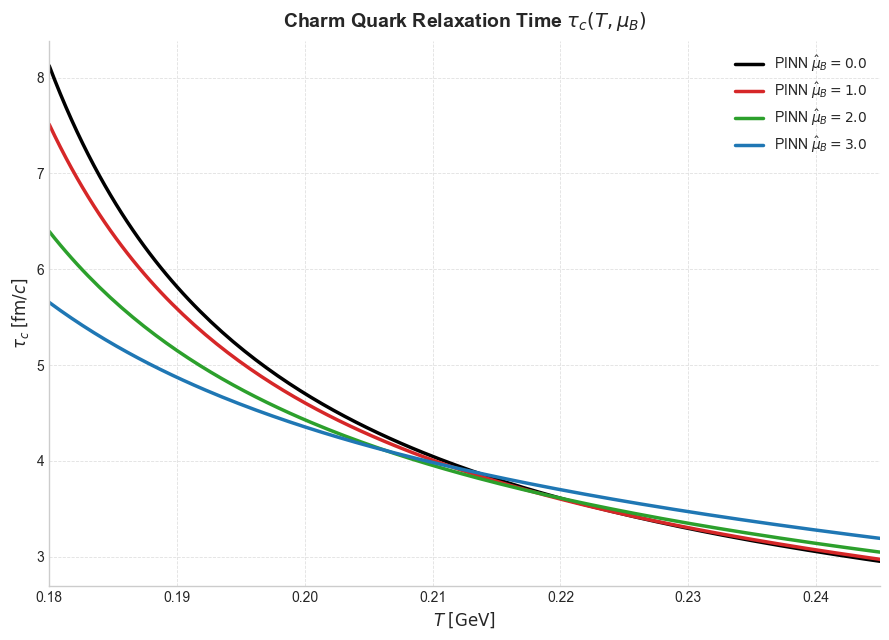

In [8]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

for ratio in RATIOS_TO_PLOT:
    res = charm_results[ratio]
    ax.plot(res.T_np, res.tau_c_fmc, color=_C_RATIO[ratio], linewidth=2.5,
             label=rf"PINN $\hat{{\mu}}_B={ratio}$")

ax.set_xlim(T_MIN_CHARM, T_MAX)
label_ax(ax, r"$T\;[\mathrm{GeV}]$", r"$\tau_c\;[\mathrm{fm}/c]$", r"Charm Quark Relaxation Time $\tau_c(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "charm_tau_c.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 7. Drag Coefficient gamma vs T



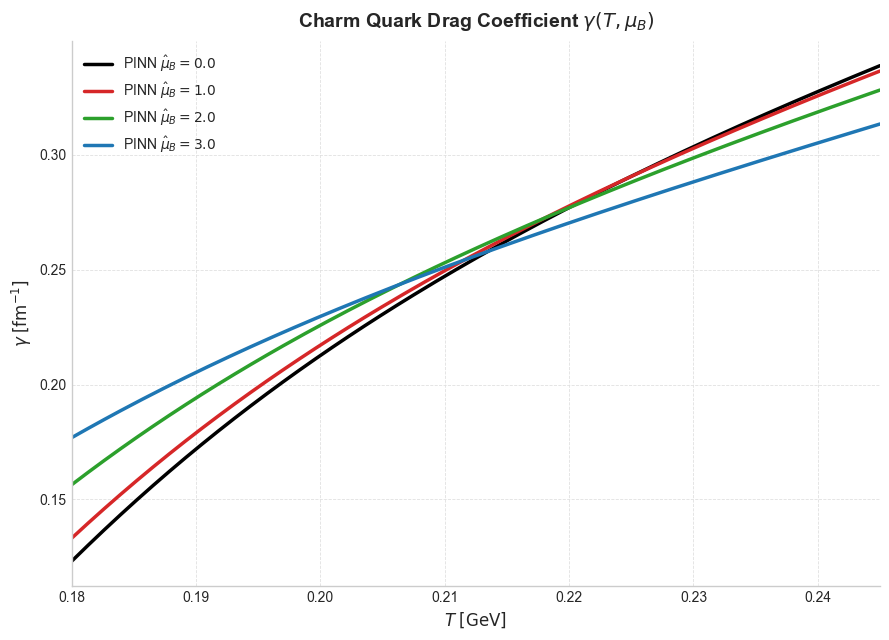

In [9]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

for ratio in RATIOS_TO_PLOT:
    res = charm_results[ratio]
    ax.plot(res.T_np, res.gamma, color=_C_RATIO[ratio], linewidth=2.5,
             label=rf"PINN $\hat{{\mu}}_B={ratio}$")

ax.set_xlim(T_MIN_CHARM, T_MAX)
label_ax(ax, r"$T\;[\mathrm{GeV}]$", r"$\gamma\;[\mathrm{fm}^{-1}]$", r"Charm Quark Drag Coefficient $\gamma(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "charm_gamma.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 8. Transverse Momentum Diffusion B0 vs T



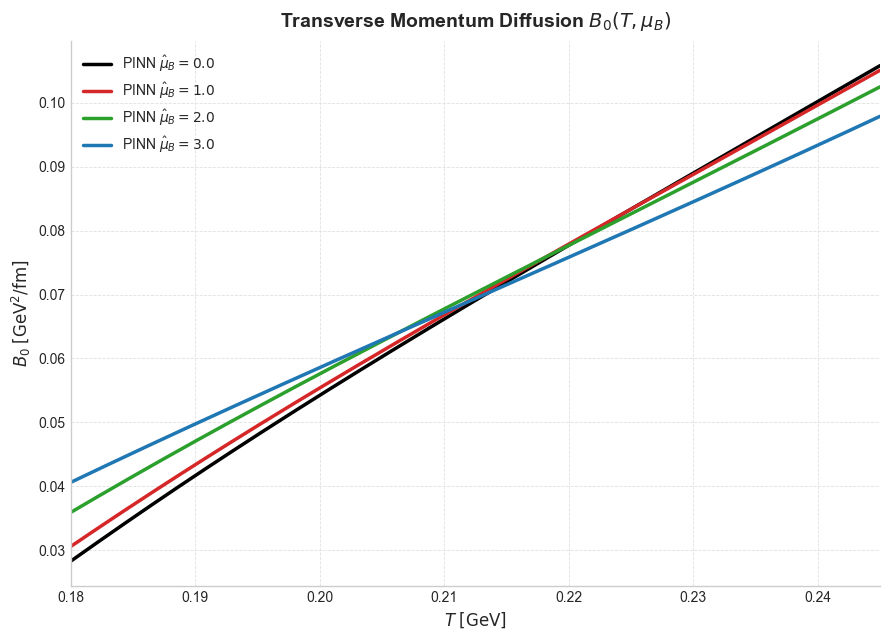

In [10]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

for ratio in RATIOS_TO_PLOT:
    res = charm_results[ratio]
    ax.plot(res.T_np, res.B0, color=_C_RATIO[ratio], linewidth=2.5,
             label=rf"PINN $\hat{{\mu}}_B={ratio}$")

ax.set_xlim(T_MIN_CHARM, T_MAX)
label_ax(ax, r"$T\;[\mathrm{GeV}]$", r"$B_0\;[\mathrm{GeV}^2/\mathrm{fm}]$", r"Transverse Momentum Diffusion $B_0(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "charm_B0.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 9. Spatial Diffusion Coefficient Ds vs T



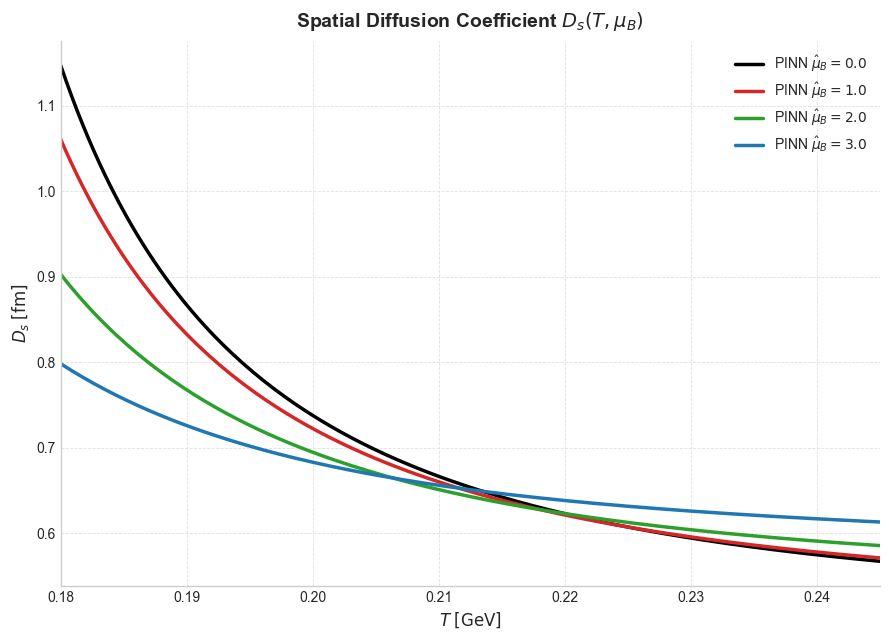

In [11]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

for ratio in RATIOS_TO_PLOT:
    res = charm_results[ratio]
    ax.plot(res.T_np, res.Ds, color=_C_RATIO[ratio], linewidth=2.5,
             label=rf"PINN $\hat{{\mu}}_B={ratio}$")

ax.set_xlim(T_MIN_CHARM, T_MAX)
label_ax(ax, r"$T\;[\mathrm{GeV}]$", r"$D_s\;[\mathrm{fm}]$", r"Spatial Diffusion Coefficient $D_s(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "charm_Ds.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 10. Export to CSV

In [12]:
import pandas as pd

all_data = []
for ratio, res in charm_results.items():
    df = pd.DataFrame({
        "muB/T": ratio, "T [GeV]": res.T_np, "T/T_c": res.T_np / T_C,
        "tau_q [fm/c]": res.tau_q_fmc, "tau_c [fm/c]": res.tau_c_fmc,
        "gamma [GeV]": res.gamma, "B0 [GeV^3]": res.B0, "Ds [GeV^-1]": res.Ds,
    })
    all_data.append(df)

out_csv = OUTPUT_DIR / "Charm_Transport_Predictions.csv"
pd.concat(all_data, ignore_index=True).to_csv(out_csv, index=False)
print(f"Data exported -> {out_csv}")

Data exported -> results\Charm_Transport_Predictions.csv
